# Setup

In [60]:
from datasets import load_dataset
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import mannwhitneyu

ds = load_dataset("AKCIT/MedPT")

# EDA

In [61]:
df = ds['train'].to_pandas()

print("\n\n======== Heads ========")
print(f"Train:\n{df.head()}\n\n")
print("======== Heads ========\n\n")

print("\n\n======== Shape ========")
print(f"Train:\n{df.shape}\n\n")
print("======== Shape ========\n\n")

print("\n\n======== Types ========")
print(f"Train:\n{df.dtypes}\n\n")
print("======== Types ========\n\n")

print("\n\n======== Amount of Null Values ========")
print(f"Train:\n{df.isna().sum()}\n\n")
print("======== Amount of Null Values ========\n\n")

print("\n\n======== Amount of Duplicate Values ========")
print(f"Train:\n{df.duplicated().sum()}\n\n")
print("======== Amount of Duplicate Values ========\n\n")

print("\n\n======== Categories ========")
print(f"Train:\n{df['question_type'].value_counts()}\n\n")
print("======== Categories ========\n\n")

print("\n\n======== Describe ========")
print(f"Train:\n{df['question_type'].describe()}\n\n")
print("======== Describe ========\n\n")




======== Heads ========
Train:
   id                                           question  \
0   0  Fazer aplicação de ácido hialurônico no ombro ...   
1   1  Fazer aplicação de ácido hialurônico no ombro ...   
2   2  Posso fazer uso regularmente de alupurinol dia...   
3   4         O que é artrite gotosa?o que provoca isto?   
4   5         O que é artrite gotosa?o que provoca isto?   

                                              answer          condition  \
0         Pode funcionar,associado com fisioterapia.  Capsulite adesiva   
1  O bloqueio do movimento causado pela Capsulite...  Capsulite adesiva   
2  Olá! Sim, pode ser necessário utilizar medicaç...     Artrite Gotosa   
3  Artrite gotosa é A inflamação de uma articulaç...     Artrite Gotosa   
4  A artrite gotosa é uma inflamação dentro da ar...     Artrite Gotosa   

                                 medical_specialty question_type  
0                    Ortopedista - traumatologista    Tratamento  
1                    

# Gráficos

<Axes: xlabel='question_type'>

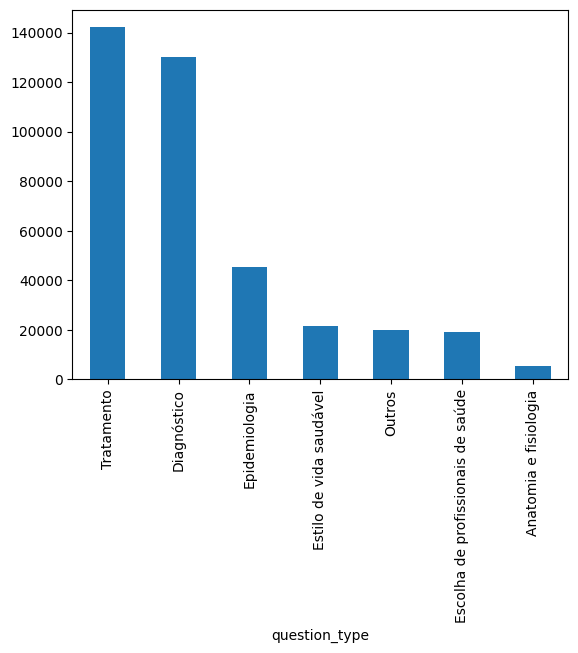

In [62]:

df['question_type'].value_counts().plot(kind="bar")

### Análise do Gráfico de Barras

É possível notar que as categorias de tratamento e diagnóstico, estão, consideravelmente mais elevadas que as demais. Isso muito provavelmente indica uma tendência dos usuários a procurarem ajuda na plataforma quando já tem algum sintoma ou problema de saúde e buscam compreender o que pode estar acontecendo ou possibilidades de tratamento.

<Axes: ylabel='Frequency'>

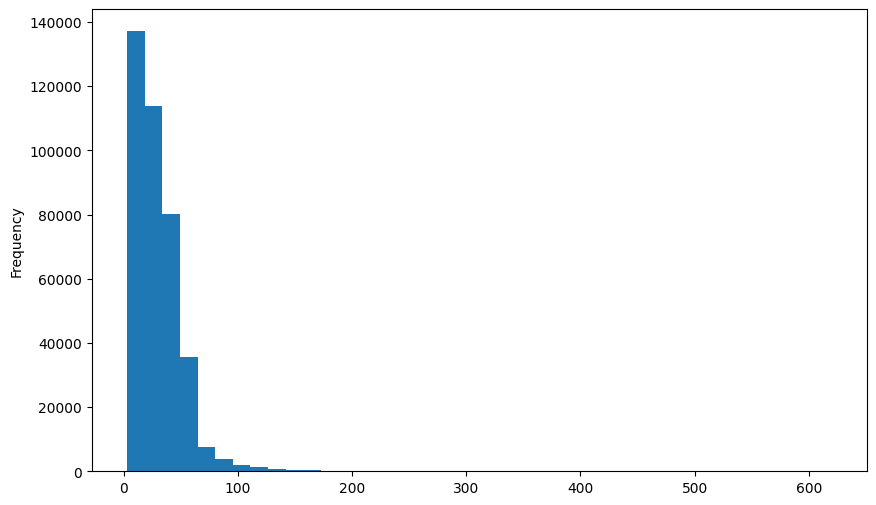

In [63]:
df["question_word_count"] = df["question"].str.split().str.len()
df["question_word_count"].plot(kind="hist", bins=40, figsize=(10, 6))

<Axes: ylabel='Frequency'>

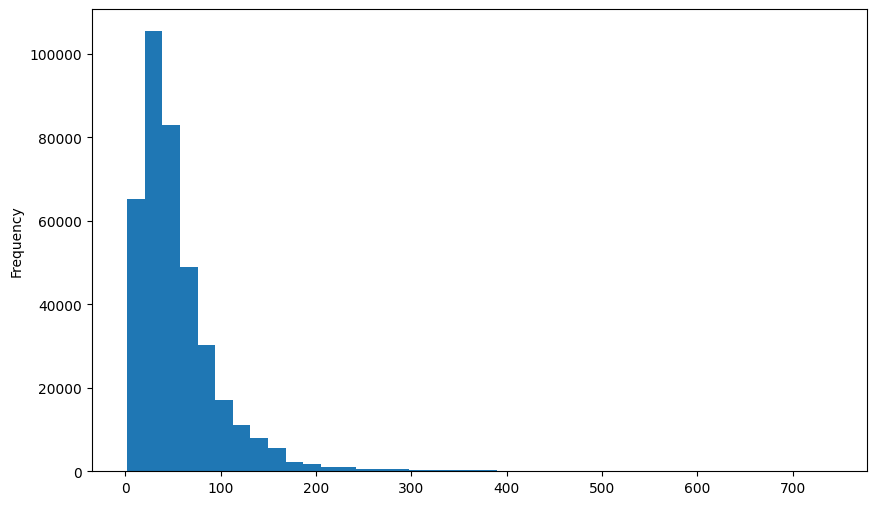

In [64]:
df["answer_word_count"] = df["answer"].str.split().str.len()
df["answer_word_count"].plot(kind="hist", bins=40, figsize=(10, 6))

### Análise Histogramas:

É notável através dos gráficos acima que a maioria das pessoas utilizaram menos de 100 palavras para descreverem suas questões, com uma aparente preferência por questões mais curtas.

Nas respostas dos profissionais a tendência é a mesma porém é visível que algumas ultrapassam esse limite podendo chegar a mais de 400 palavras.

Isso é interessante pois indica que podemos esperar entradas mais curtas mas que devemos estar preparados para as raras ocasiões onde o usuário coloque uma entrada mais extensa e descritiva.

<Axes: title={'center': 'question_word_count'}, xlabel='[question_type]'>

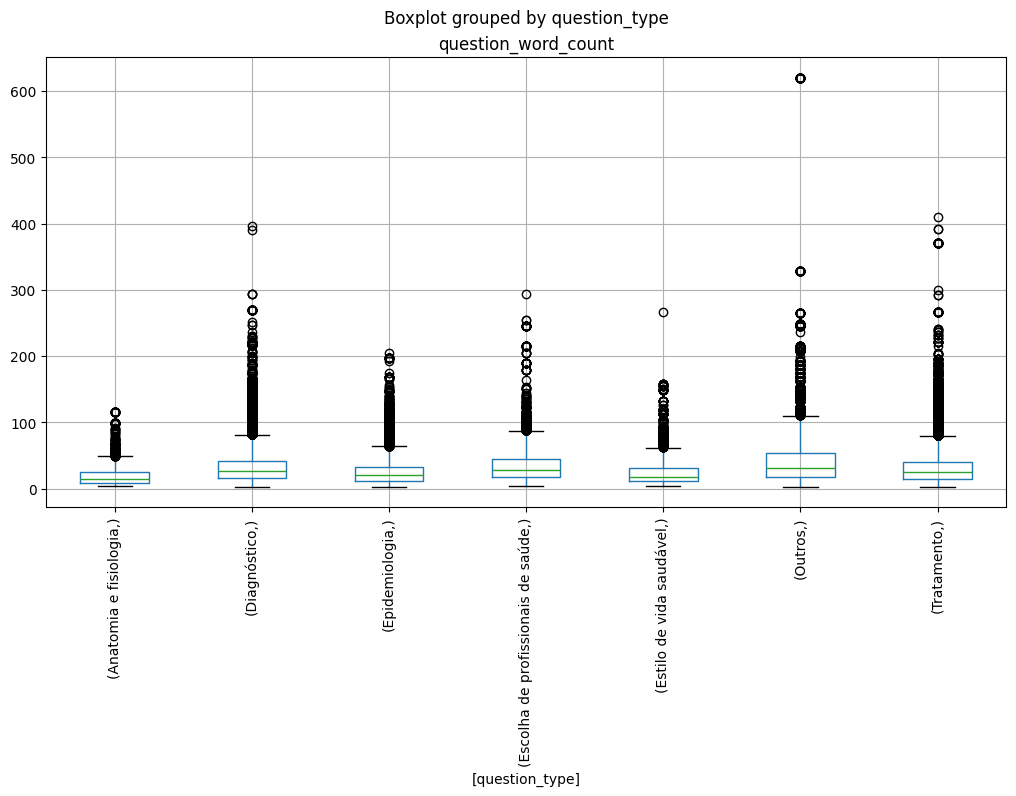

In [65]:
df.boxplot(column=["question_word_count"], by=["question_type"], figsize=(12, 6), rot=90)

<Axes: title={'center': 'answer_word_count'}, xlabel='[question_type]'>

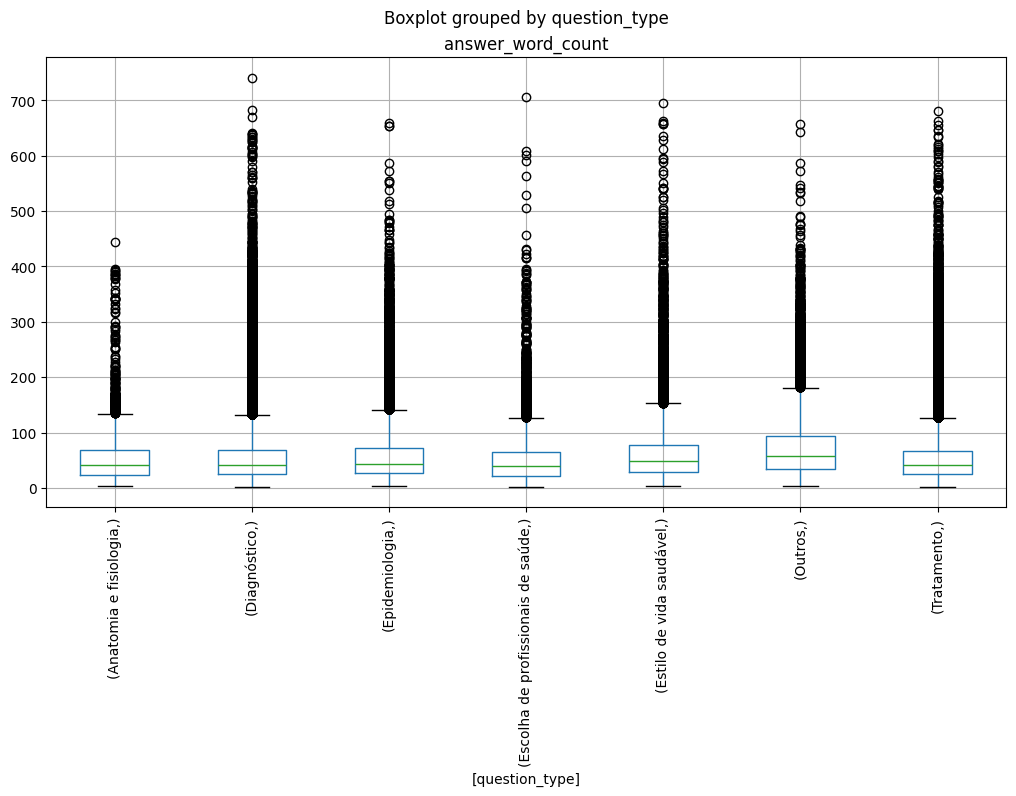

In [66]:
df.boxplot(column=["answer_word_count"], by=["question_type"], figsize=(12, 6), rot=90)

### Análise Boxplots

Os boxplots reforçam os histogramas, mostrando que na maioria das categorias as perguntas se concentram em uma mediana de aproximadamente 15 a 40 palavras, ao mesmo tempo, vemos algo que estava mais discreto ou até mesmo não visível nos histogramas, os outliers que podem chegar a 300, 400 ou até mesmo 600 palavras, portanto, mesmo que o comportamento típico seja de uma mediana de aproximadamente de 15 a 40 palavras, não podemos assumir que o usuário final sempre vai inserir um tamanho nessa média.

Nas respostas dos profissionais é possível observar o mesmo padrão, com a grande maioria tendo uma mediana de aproximadamente de 40 a 60 palavras, mas com grande número de outliers chegando a 600 e até mesmo a 700 palavras, demonstrando grande diversidade no tamanho das respostas fornecidas, também é notavel que algumas categorias como “Estilo de Vida Saudável” ou “Outros” tem uma média maior de palavras, o que pode indicar que algumas categorias tendem a demandar respostas mais explicativas e maiores.

#TP 2

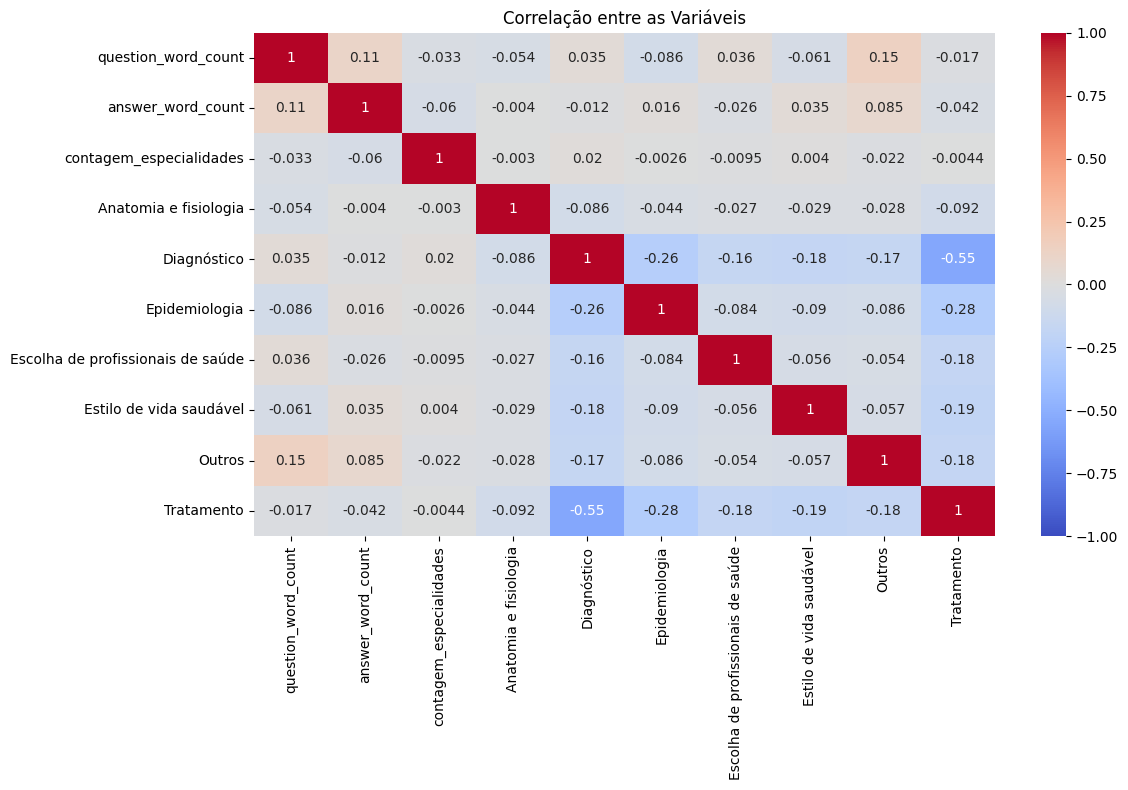

<Axes: xlabel='especialidade_principal', ylabel='question_type'>

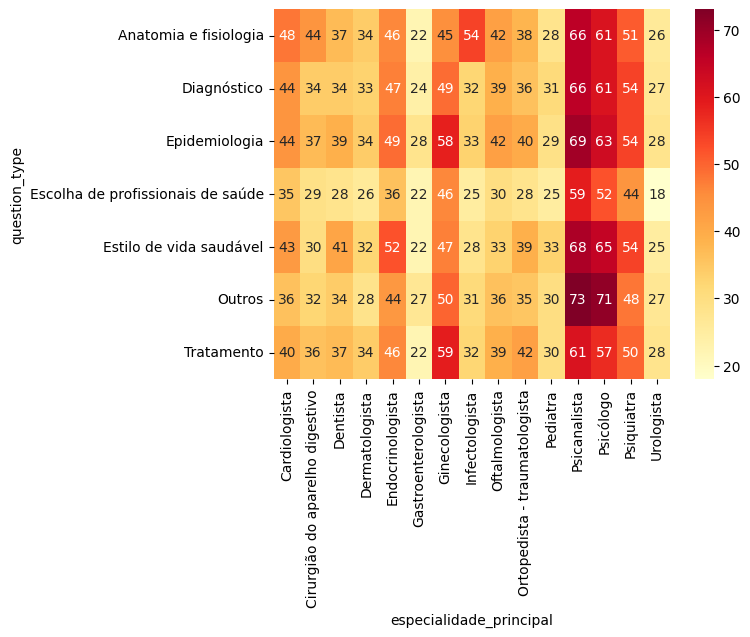

In [67]:
df["contagem_especialidades"] = df["medical_specialty"].fillna("").apply(
    lambda x: len(x.split(",")) if x else 0
)

tipos = pd.get_dummies(df["question_type"], dtype=int)

df_corr = pd.concat([df[["question_word_count", "answer_word_count", "contagem_especialidades"]], tipos], axis=1)

plt.figure(figsize=(12, 8))

sns.heatmap(
    df_corr.corr(),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
)

plt.title("Correlação entre as Variáveis")
plt.tight_layout()
plt.show()

df["especialidade_principal"] = (
    df["medical_specialty"].str.split(",").str[0].str.strip()
)

df_heat = df[df["especialidade_principal"].isin(df["especialidade_principal"].value_counts().head(15).index)]

heatmap = df_heat.pivot_table(
    index="question_type",
    columns="especialidade_principal",
    values="answer_word_count",
    aggfunc="median"
)

sns.heatmap(heatmap, cmap="YlOrRd", annot=True)


Analisando o heatmap acima, é possível ver com um pouco mais de clareza a correlação entre o tamanho da resposta e os tipos de questões, e parece que assim como tinhamos visto, existe uma correlação, apesar de pequena entre a quantia de palavras nas respostas e o tipo da pergunta, visto que nas categorias outro e estilo de vida saudável como tinhamos levantado aparece uma correlação maior.

<Axes: title={'center': 'Pergunta x Resposta'}, xlabel='question_word_count', ylabel='answer_word_count'>

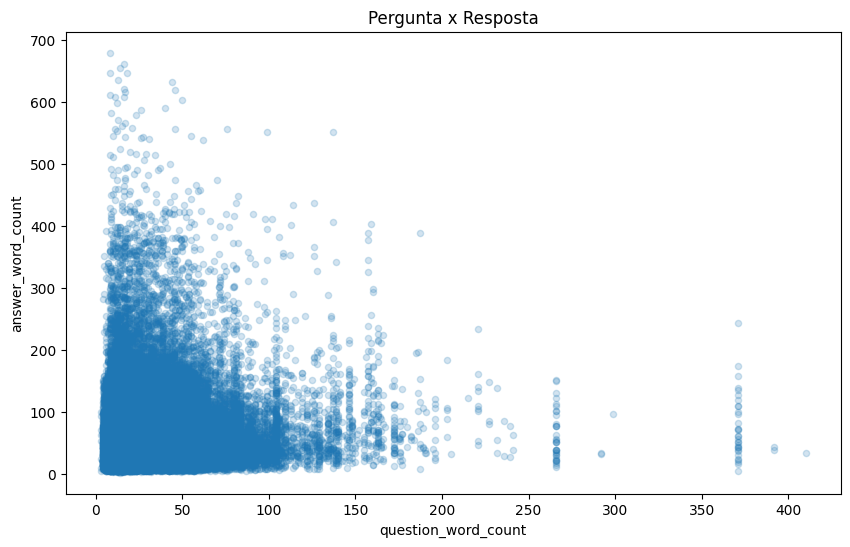

In [68]:
df[df["question_type"] == "Tratamento"].plot.scatter(
    x="question_word_count", y="answer_word_count", figsize=(10, 6), alpha=0.2, title="Pergunta x Resposta"
  )

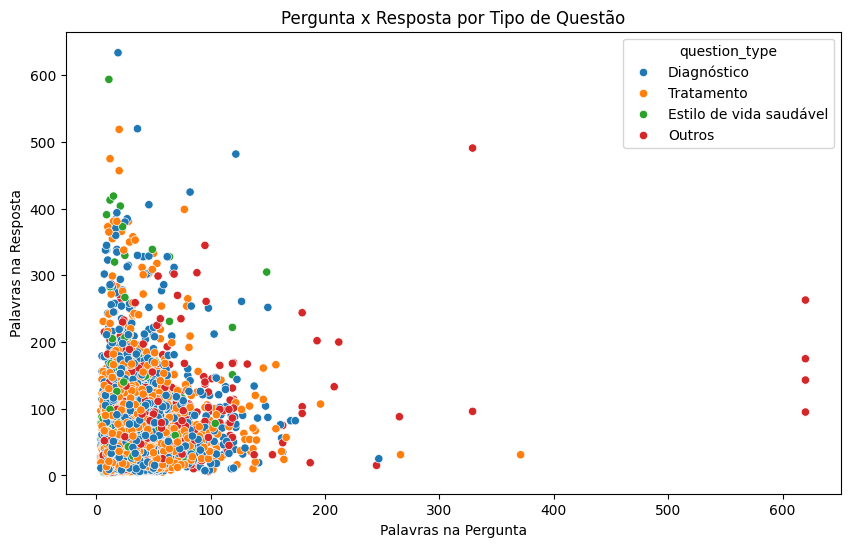

In [69]:
df_scatter = df[df["question_type"].isin(["Tratamento", "Diagnóstico", "Estilo de vida saudável", "Outros"])].sample(10000, random_state=42)

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_scatter, x="question_word_count", y="answer_word_count", hue="question_type")

plt.title("Pergunta x Resposta por Tipo de Questão")
plt.xlabel("Palavras na Pergunta")
plt.ylabel("Palavras na Resposta")
plt.show()

Baseado na análise feita desde o tp-1 até o presente momento e observando os scatterplots e os heatmaps gerados, decidi dar continuidade na hipotese levantada no tp-1 que é:

h0 - As respostas da categoria de estilo de vida saudavel não tendem a ser maiores que as respostas da categoria de Tratamento

h1 - As respostas da categoria de estilo de vida saudavel tendem a ser maiores que as respostas da categoria de Tratamento

Como existem muitos outliers e respostas que podem ir de 20 palavras até 600 palavras decidi usar mann-whitney ao invés de t-test.

In [74]:
estilo = df[df["question_type"] == "Estilo de vida saudável"]["answer_word_count"].dropna()
tratamento = df[df["question_type"] == "Tratamento"]["answer_word_count"].dropna()

print(f"Mediana de Estilo de vida saudável: {estilo.median()}")
print(f"Mediana de Tratamento: {tratamento.median()}")

u, p_valor = mannwhitneyu(estilo, tratamento, alternative="greater")

print(f"\n\nU: {u}")
print(f"P valor: {p_valor}")

Mediana de Estilo de vida saudável: 48.0
Mediana de Tratamento: 41.0


U: 1715493161.5
P valor: 3.6006338519089664e-151


O teste com Mann-Whitney apresentou um p-valor inferior a 0,05, encontramos então evidencias estatísticas de que as respostas ligadas a Estilo de vida saudável são maiores que as respostas da categoria Tratamento, ou seja, existem categorias cujas respostas são mais complexas.

## Relatório EDA

O relatório vai estar em um arquivo separado e para a elaboração das seções textuais do EDA, utilizei o modelo ChatGPT, desenvolvido pela OpenAI.

A ferramenta foi alimentada com o contexto do conjunto de dados, as hipóteses validadas e os outputs estatísticos obtidos nas etapas anteriores, fiz uso do modelo na estruturação e refinamento da escrita acadêmica, seguindo as categorias solicitadas na Questão 7.